In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

Data =pd.read_csv("diabetes_prediction_dataset.csv")
x=Data[["age",
        "hypertension",
        "heart_disease",
        "smoking_history",
        "bmi",
        "HbA1c_level",
        "blood_glucose_level",
        "gender"]]

y=Data["diabetes"]

df=pd.DataFrame(Data)
print(df.isnull().sum())

cat_col=["smoking_history","gender"]
num_col=["blood_glucose_level","bmi","HbA1c_level","hypertension","heart_disease","age"]



gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [6]:
ohe=OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore",
)

encoded=ohe.fit_transform(x[cat_col])
encoded_df=pd.DataFrame(encoded,
                        columns=ohe.get_feature_names_out(cat_col)
                        )

x_final=np.concatenate([encoded_df,x[num_col]], axis=1)
print(x_final)

[[ 0.  0.  0. ...  0.  1. 80.]
 [ 1.  0.  0. ...  0.  0. 54.]
 [ 0.  0.  0. ...  0.  0. 28.]
 ...
 [ 0.  0.  0. ...  0.  0. 66.]
 [ 0.  0.  0. ...  0.  0. 24.]
 [ 0.  1.  0. ...  0.  0. 57.]]


In [9]:
X_train,X_test,Y_train,Y_test = train_test_split(
    x_final,y,test_size=0.3,train_size=0.7,random_state=42
)

In [10]:
model=RandomForestClassifier()
model.fit(X_train,Y_train)
y_pred=model.predict(X_test)
print(accuracy_score(Y_test,y_pred))
print(recall_score(Y_test,y_pred))
print(f1_score(Y_test,y_pred))
print(precision_score(Y_test,y_pred))

0.9702666666666667
0.6843345111896348
0.7962539972590224
0.9519388312397596


In [13]:
gender=input("enter your gender")
age=input("enter your age:")
hypertension=input("enter your hypertension:")
heart_disease=input("enter heart_disease 1=yes or 0=no:")
smoking_history=input("enter smoking_history: current or No Info or never or former:")
bmi=input("enter your bmi:")
HbA1c_level=input("enter your HbA1c_level:")
blood_glucose_level=input("enter your blood_glucose_level:")

new_data=pd.DataFrame(
    {
        "gender":[gender],
        "age":[age],
        "hypertension":[hypertension],
        "heart_disease":heart_disease,
        "smoking_history":[smoking_history],
        "bmi":[bmi],
        "HbA1c_level":[HbA1c_level],
        "blood_glucose_level":[blood_glucose_level],
    }
)



In [21]:
new_encoded = ohe.transform(
    new_data[cat_col]
)

new_encoded_df = pd.DataFrame(
    new_encoded,
    columns=ohe.get_feature_names_out(cat_col)
)

x_last = np.concatenate(
    [
        new_encoded_df.values,
        new_data[num_col].values
    ],
    axis=1
)

In [28]:
new_prediction = model.predict(x_last)

print("Having Diabetes Prediction:", new_prediction[0])


result = "Having Diabetes" if new_prediction[0] == 1 else "Not Having Diabetes"
print("person", result)

Having Diabetes Prediction: 1
person Having Diabetes


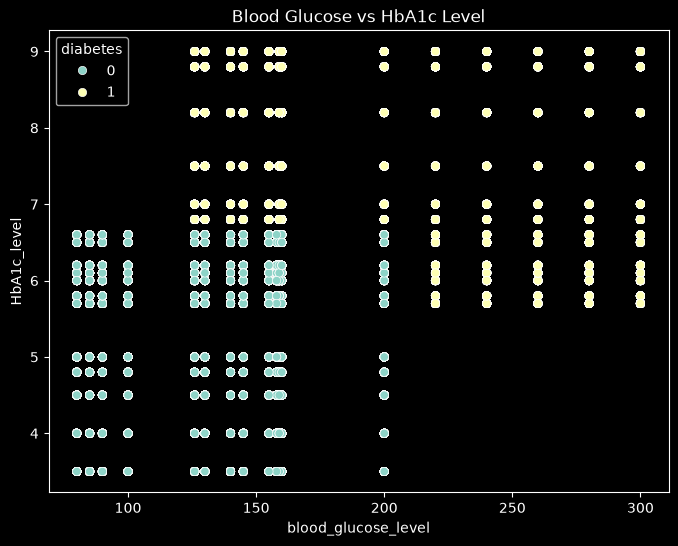

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="blood_glucose_level",
    y="HbA1c_level",
    hue="diabetes",
    data=Data
)

plt.title("Blood Glucose vs HbA1c Level")

plt.show()



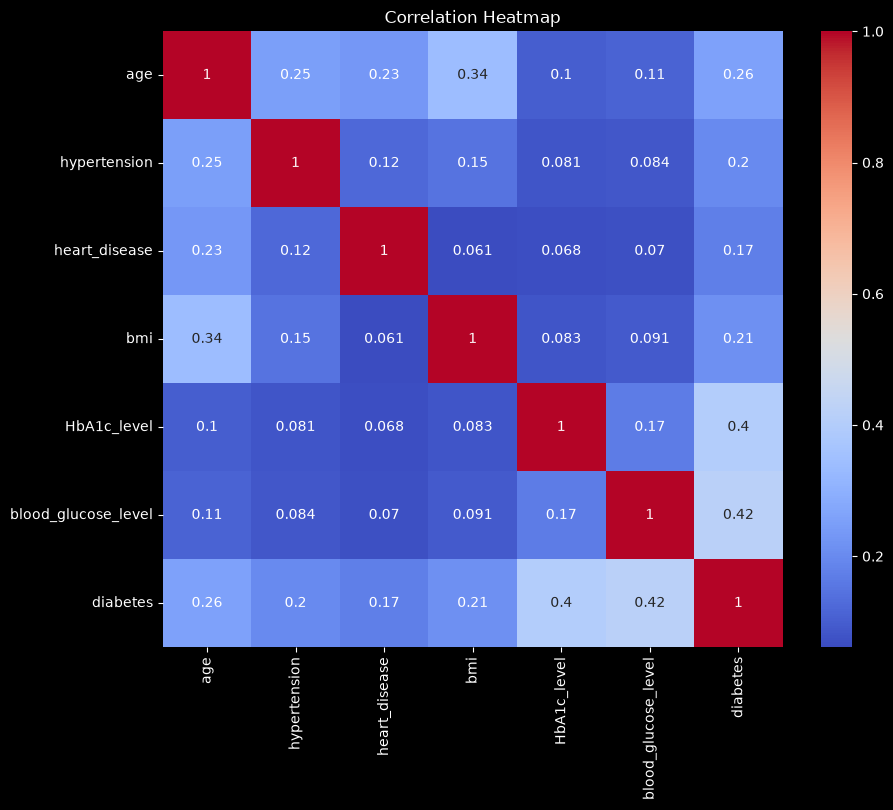

In [32]:
plt.figure(figsize=(10,8))

sns.heatmap(



    Data.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

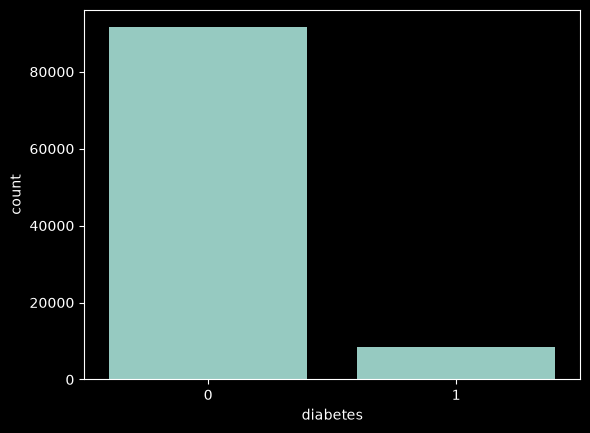

In [40]:

sns.countplot(x="diabetes", data=Data)
plt.show()

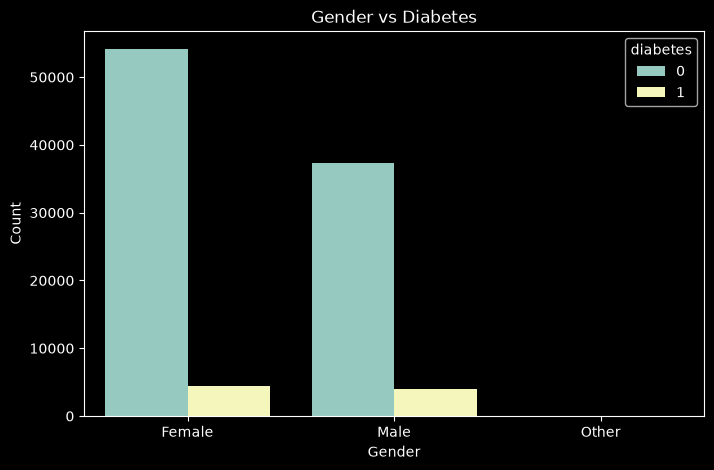

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="gender",
    hue="diabetes",
    data=Data
)

plt.title("Gender vs Diabetes")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()